In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.decomposition import NMF # 비음수 행렬 분해 알고리즘을 사용하기 위해 import 한다.

비음수 행렬 분해(Non-negative Matrix Factorization, NMF)

비음수 행렬 분해는 행렬 내 모든 원소값이 0이상인 경우 사용할 수 있는 행렬 분해 방법이다.

비음수 행렬 분해 알고리즘을 이용해서 사이킷런이 제공하는 얼굴 이미지 데이터에서 사람 얼굴의 특징 요소를 추출하는 모델을 생성해 본다.  
비음수 행렬 분해에서 사용하는 데이터는 성분이 모두 움수가 아닌 성분이어야 하므로 주로 이미지 데이터나 음성 데이터와 같이 음수값이 없는 데이터가 많이 사용된다.

컬러 이미지로 읽기

In [2]:
# fetch_lfw_people() 메소드로 사이킷런이 제공하는 얼굴 이미지 데이터를 불러온다.
# min_faces_per_person 속성의 기본값은 0이고 얼굴 이미지 데이터 중 지정한 속성값 이상 같은 인물이 있는 경우 얼굴 데이터를 읽어온다.
# resize 속성의 기본값은 0.5이고 얼굴 이미지 데이터 크기를 지정한다.
# color 속성의 기본값은 False이고 흑백 이미지로 읽어오고 True를 지정하면 컬러 이미지로 읽어온다.
raw_data = datasets.fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True)

사이킷런이 제공하는 컬러 얼굴 이미지 살펴보기

컬러 이미지의 각 픽셀은 각 채널(`R(빨강), G(녹색), B(파랑)`)별로 각각 0에서 255 사이의 값을 가지며 채널의 개수가 3개가 나온다.

In [3]:
n, h, w, c = raw_data.images.shape
print(f'읽어온 이미지 수: {n}, 이미지 세로 크기: {h}, 이미지 가로 크기: {w}, 채널 개수: {c}')

# raw_data.data.shape은 채널이 3개인 얼굴 이미지 데이터 행렬을 늘어뜨려 1차원으로 나타낸 데이터
xData = raw_data.data # 피쳐(얼굴 이미지)
row, col = xData.shape
# row가 3023인 이유는 fetch_lfw_people() 메소드의 min_faces_per_person 속성을 지정한 조건을 만족하는 이미지의 개수가 3023개 이기 때문이고 col이 35250인 이유는
# raw_data.images.shape의 실행 결과가 (3023, 125, 94, 3)이고 이미지의 크기와 채널의 개수를 의미하는 125, 94, 3를 1차원으로 늘어뜨리면 35250이기 때문이다.
print(f'row: {row}, col: {col}')

yData = raw_data.target # 피쳐(얼굴 이미지)에 따른 레이블
target_names = raw_data.target_names # 피쳐(얼굴 이미지)에 따른 사람 이름
print(f'{row}개의 얼굴 이미지를 구성하는 인물의 수는 {target_names.shape[0]}명 이다.')

읽어온 이미지 수: 3023, 이미지 세로 크기: 125, 이미지 가로 크기: 94, 채널 개수: 3
row: 3023, col: 35250
3023개의 얼굴 이미지를 구성하는 인물의 수는 62명 이다.


In [4]:
# 학습 데이터와 테스트 데이터로 분할한다.
x_train, x_test, y_train, y_test = train_test_split(xData, yData, random_state=1)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2267, 35250) (756, 35250) (2267,) (756,)


비음수 행렬 분해 전 오리지널 컬러 이미지 시각화

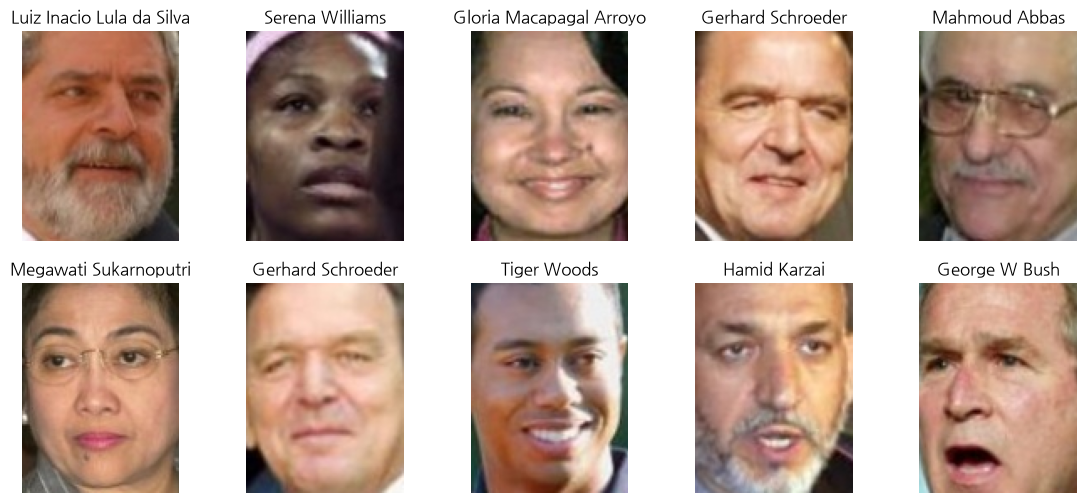

In [5]:
plt.figure(figsize=[14, 6])
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # imshow() 메소드는 컬러 이미지를 출력할 때 reshape(h, w, 3) 메소드 실행 하고 255를 곱한 후 astype() 메소드를 실행해서 부호 없는 8비트 정수로 데이터 타입을
    # 변경한다.
    plt.imshow((x_train[i].reshape(h, w, 3) * 255).astype(np.uint8))
    plt.axis('off')
    plt.title(target_names[y_train[i]])
plt.show()

비음수 행렬 분해를 이용한 차원 축소

In [6]:
# n_components 속성값에 축소하려는 차원 크기를 지정하고 비음수 행렬 분해 모델을 만든다.
model_nmf = NMF(n_components=10) # 35250 차원의 데이터를 10차원으로 축소한다.

# 비음수 행렬 분해는 지도 학습적인 접근 방법이므로 표준화 스케일러로 표준화한 학습 데이터와 학습 데이터에 따른 레이블을 넘겨서 학습시킨다.
# model_nmf.fit(x_train, y_train)
# 비음수 행렬 분해 모델에 학습 데이터를 적용한다.
# x_train_nmf = model_nmf.transform(x_train)
x_train_nmf = model_nmf.fit_transform(x_train, y_train)

# 표준화 스케일러의 사용 방법과 마찬가지로 학습은 학습 데이터로만 해야하고 테스트 데이터는 학습 데이터로 학습된 결과에 적용만 시킨다.
x_test_nmf = model_nmf.transform(x_test)
print(x_train.shape, x_train_nmf.shape, x_test.shape, x_test_nmf.shape)

(2267, 35250) (2267, 10) (756, 35250) (756, 10)


In [7]:
# 비음수 행렬 분해 벡터 확인
# components_ 속성으로 비음수 행렬 분해 벡터를 확인할 수 있다.
print(model_nmf.components_.shape)
print(model_nmf.components_)

(10, 35250)
[[1.12883520e+00 5.75671315e-01 1.07863754e-01 ... 1.59677789e-02
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.41940546e+01
  1.50764751e+01 1.53472834e+01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.16809174e-01]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.75204054e-02 3.28648463e-02]
 [0.00000000e+00 0.00000000e+00 2.21874565e-03 ... 1.20661986e+00
  1.04710388e+00 9.57013667e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


비음수 행렬 분해 후 차원 축소된 컬러 이미지 시각화

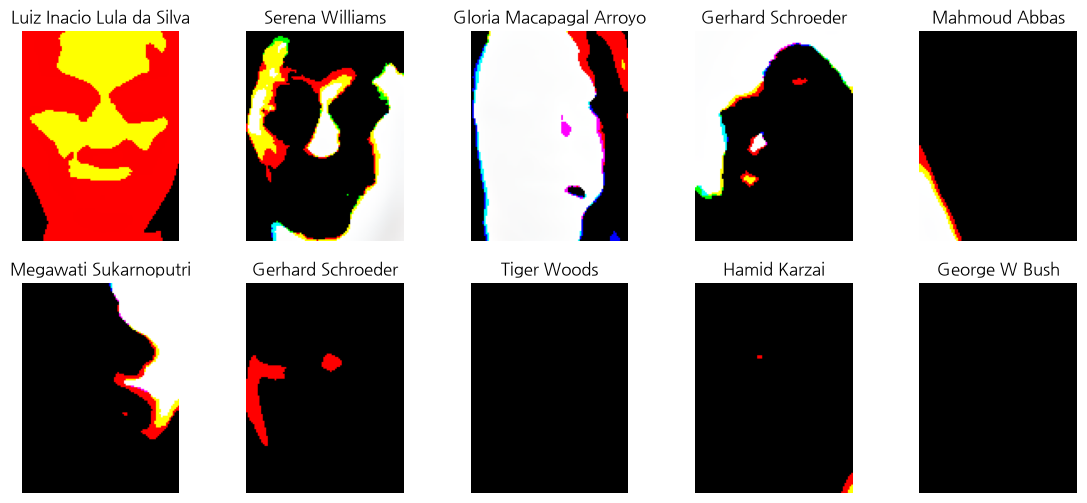

In [12]:
plt.figure(figsize=[14, 6])
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow((model_nmf.components_[i].astype(np.uint8) * 255).reshape(h, w, 3))
    plt.axis('off')
    plt.title(target_names[y_train[i]])
plt.show()

흑백 이미지로 읽기

In [13]:
raw_data = datasets.fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=False)

In [14]:
# 흑백 이미지는 그레이스케일로 0에서 255 사이의 단일 채널이므로 채널의 개수가 리턴되지 않는다.
n, h, w = raw_data.images.shape
print(f'읽어온 이미지 수: {n}, 이미지 세로 크기: {h}, 이미지 가로 크기: {w}')

# raw_data.data.shape은 그레이스케일 2차원 얼굴 이미지 데이터 행렬을 늘어뜨려 1차원으로 나타낸 데이터
xData = raw_data.data # 피쳐(얼굴 이미지)
row, col = xData.shape
# row가 3023인 이유는 fetch_lfw_people() 메소드의 min_faces_per_person 속성을 지정한 조건을 만족하는 이미지의 개수가 3023개 이기 때문이고 col이 35250인 이유는
# raw_data.images.shape의 실행 결과가 (3023, 125, 94, 3)이고 이미지의 크기와 채널의 개수를 의미하는 125, 94, 3를 1차원으로 늘어뜨리면 35250이기 때문이다.
print(f'row: {row}, col: {col}')

yData = raw_data.target # 피쳐(얼굴 이미지)에 따른 레이블
target_names = raw_data.target_names # 피쳐(얼굴 이미지)에 따른 사람 이름
print(f'{row}개의 얼굴 이미지를 구성하는 인물의 수는 {target_names.shape[0]}명 이다.')

읽어온 이미지 수: 3023, 이미지 세로 크기: 125, 이미지 가로 크기: 94
row: 3023, col: 11750
3023개의 얼굴 이미지를 구성하는 인물의 수는 62명 이다.


In [15]:
# 학습 데이터와 테스트 데이터로 분할한다.
x_train, x_test, y_train, y_test = train_test_split(xData, yData, random_state=1)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2267, 11750) (756, 11750) (2267,) (756,)


비음수 행렬 분해 전 오리지널 흑백 이미지 시각화

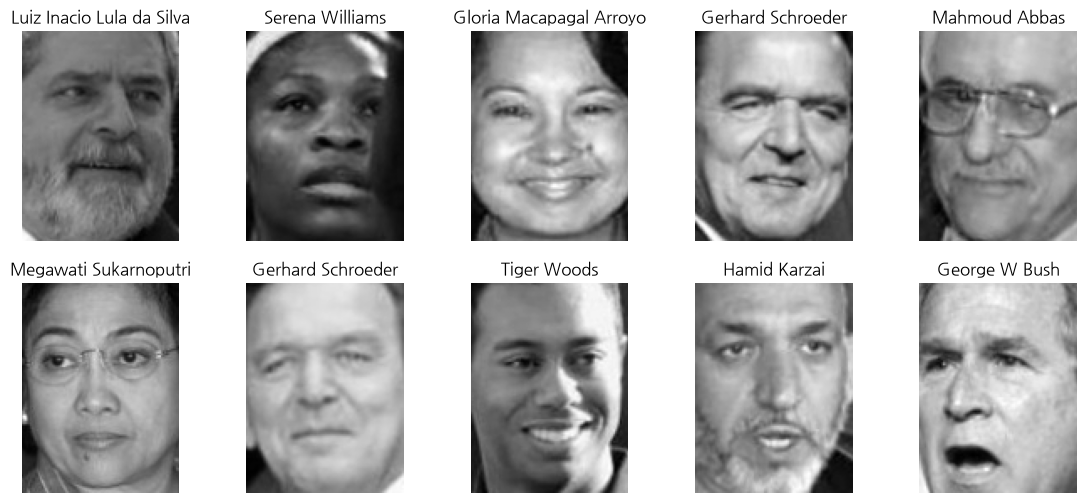

In [16]:
plt.figure(figsize=[14, 6])
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # imshow() 메소드는 흑백 이미지를 출력할 때 reshape(h, w) 메소드 실행 하고 255를 곱한 후 astype() 메소드를 실행해서 부호 없는 8비트 정수로 데이터 타입을
    # 변경한다.
    plt.imshow((x_train[i].reshape(h, w) * 255).astype(np.uint8), cmap='gray')
    plt.axis('off')
    plt.title(target_names[y_train[i]])
plt.show()

In [17]:
# n_components 속성값에 축소하려는 차원 크기를 지정하고 비음수 행렬 분해 모델을 만든다.
model_nmf = NMF(n_components=10) # 35250 차원의 데이터를 10차원으로 축소한다.

# 비음수 행렬 분해는 지도 학습적인 접근 방법이므로 표준화 스케일러로 표준화한 학습 데이터와 학습 데이터에 따른 레이블을 넘겨서 학습시킨다.
# model_nmf.fit(x_train, y_train)
# 비음수 행렬 분해 모델에 학습 데이터를 적용한다.
# x_train_nmf = model_nmf.transform(x_train)
x_train_nmf = model_nmf.fit_transform(x_train, y_train)

# 표준화 스케일러의 사용 방법과 마찬가지로 학습은 학습 데이터로만 해야하고 테스트 데이터는 학습 데이터로 학습된 결과에 적용만 시킨다.
x_test_nmf = model_nmf.transform(x_test)
print(x_train.shape, x_train_nmf.shape, x_test.shape, x_test_nmf.shape)

(2267, 11750) (2267, 10) (756, 11750) (756, 10)


In [18]:
# 비음수 행렬 분해 벡터 확인
# components_ 속성으로 비음수 행렬 분해 벡터를 확인할 수 있다.
print(model_nmf.components_.shape)
print(model_nmf.components_)

(10, 11750)
[[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 2.6082847e+00
  2.4423397e+00 2.4051676e+00]
 [8.6184964e-02 8.2110882e-02 7.6339632e-02 ... 2.4455597e-01
  2.5673056e-01 2.6944104e-01]
 ...
 [2.7416116e-03 1.8247752e-03 4.0384014e-03 ... 1.9163374e+00
  1.8379272e+00 1.7464993e+00]
 [1.6452296e-01 1.8453483e-01 1.9503264e-01 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 6.9274640e-05 2.5276661e-02 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]]


비음수 행렬 분해 후 차원 축소된 흑백 이미지 시각화

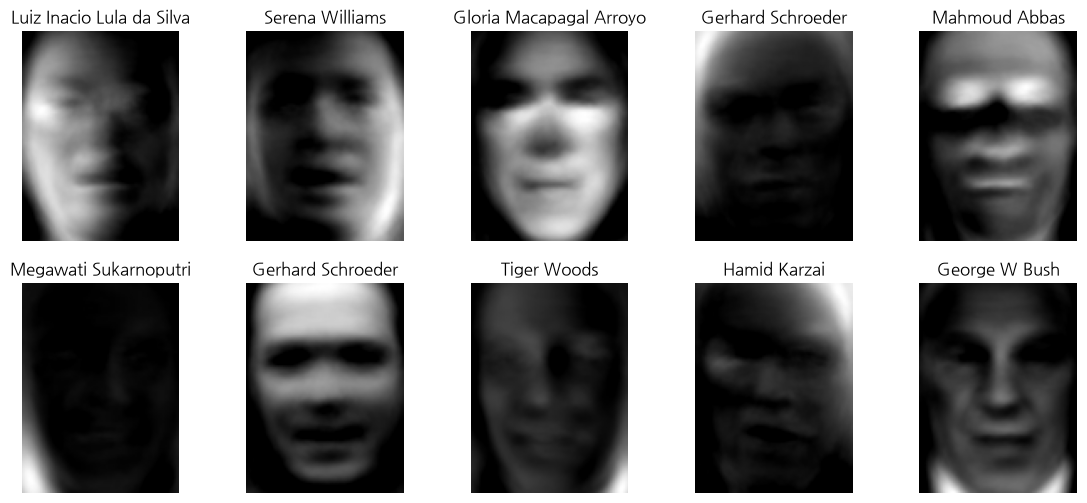

In [19]:
plt.figure(figsize=[14, 6])
plt.gray()
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(model_nmf.components_[i].reshape(h, w))
    plt.axis('off')
    plt.title(target_names[y_train[i]])
plt.show()